In [17]:
ATHLETE_NAME   = 'Mircea'
AGE            = 22
DATA_DIR       = '../data/Mircea'
OUT_DIR        = f'../data/analysis_{ATHLETE_NAME}'
RUNNING_SPORTS = {'running', 'trail_running'}

ZONE_BOUNDS = [0.00, 0.60, 0.70, 0.80, 0.90, 1.01]
ZONE_LABELS = ['Z1 Recovery', 'Z2 Aerobic', 'Z3 Tempo', 'Z4 Threshold', 'Z5 VO2max']
ZONE_COLORS = ['#4FC3F7', '#81C784', '#FFD54F', '#FF8A65', '#E57373']

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Athlete: {ATHLETE_NAME}  |  Age: {AGE}')

Athlete: Mircea  |  Age: 22


In [18]:
sessions = pd.read_parquet(f'{DATA_DIR}/sessions.parquet')
records  = pd.read_parquet(f'{DATA_DIR}/records.parquet')

runs    = sessions[sessions['sport'].isin(RUNNING_SPORTS)].copy()
run_ids = set(runs['session_id'])
run_rec = records[records['session_id'].isin(run_ids)].copy()

# ── Estimate MAX_HR ──────────────────────────────────────────────────────────
# Primary: 99th percentile of raw HR across all running records.
# At this sample size, sits above noise but below extreme outlier spikes.
formula_hr = round(211 - 0.64 * AGE)
data_hr    = int(run_rec['heart_rate'].quantile(0.99))

# Sanity check: if data estimate is >10 bpm below the formula, the dataset
# likely contains no hard efforts — fall back to the formula.
if data_hr >= formula_hr - 10:
    MAX_HR = data_hr
    hr_source = 'data (99th percentile)'
else:
    MAX_HR = formula_hr
    hr_source = f'formula fallback — data 99th pct ({data_hr} bpm) is >10 below formula'

print(f'Running sessions : {len(runs)}')
print(f'Running records  : {len(run_rec):,}')
print(f'Date range       : {runs["date"].min().date()} → {runs["date"].max().date()}')
print(f'Formula max HR   : {formula_hr} bpm  (211 - 0.64 × {AGE})')
print(f'Data 99th pct    : {data_hr} bpm')
print(f'Using MAX_HR     = {MAX_HR} bpm  [{hr_source}]')

Running sessions : 98
Running records  : 212,720
Date range       : 2025-11-05 → 2026-04-16
Formula max HR   : 197 bpm  (211 - 0.64 × 22)
Data 99th pct    : 199 bpm
Using MAX_HR     = 199 bpm  [data (99th percentile)]


## HR zones vs Speed

In [19]:
# ── Session-level aggregation ────────────────────────────────────────────────
# Strip first 120s of each session (cardiac lag), then compute per-session
# mean HR and mean speed. One row per run — avoids intra-session noise.
def summarise_session(grp):
    grp = grp.sort_values('timestamp')
    t0  = grp['timestamp'].min()
    grp = grp[grp['timestamp'] >= t0 + pd.Timedelta(seconds=120)]
    grp = grp[grp['speed_ms'] >= 1.5]
    if grp.empty:
        return None
    return pd.Series({
        'mean_hr':    grp['heart_rate'].mean(),
        'mean_speed': grp['speed_ms'].mean(),
        'n_records':  len(grp),
    })

session_stats = (
    run_rec.groupby('session_id')
    .apply(summarise_session)
    .dropna()
    .reset_index()
)
session_stats = session_stats.merge(
    runs[['session_id', 'date']], on='session_id', how='left'
)

def assign_zone(hr):
    if pd.isna(hr): return np.nan
    pct = hr / MAX_HR
    for i in range(len(ZONE_BOUNDS) - 1):
        if ZONE_BOUNDS[i] <= pct < ZONE_BOUNDS[i + 1]:
            return ZONE_LABELS[i]
    return np.nan

session_stats['hr_zone'] = session_stats['mean_hr'].apply(assign_zone)
session_stats['hr_zone'] = pd.Categorical(
    session_stats['hr_zone'], categories=ZONE_LABELS, ordered=True
)

print(f'Sessions with valid data: {len(session_stats)}')
print(f'\nSessions per zone:')
for z, n in session_stats['hr_zone'].value_counts().reindex(ZONE_LABELS).items():
    print(f'  {z:<20s} {n:>3} sessions')

Sessions with valid data: 98

Sessions per zone:
  Z1 Recovery            0 sessions
  Z2 Aerobic             2 sessions
  Z3 Tempo              22 sessions
  Z4 Threshold          64 sessions
  Z5 VO2max             10 sessions


Regression  speed = 0.0249 × HR + -1.127  (R²=0.58, p=0.000)
Interpretation: 0.249 m/s per 10 bpm  (faster with higher HR)

Zone                    n   Speed (m/s)        Pace             95% CI (pace)  Source
------------------------------------------------------------------------------------------
Z1 Recovery             0     2.31 m/s  7:12 min/km                         —  regression
Z2 Aerobic              2     2.31 m/s  7:12 min/km                         —  blend (20% emp) [mono-corrected]  ⚠ low n
Z3 Tempo               22     2.72 m/s  6:08 min/km  [5:50 min/km, 6:14 min/km]  empirical
Z4 Threshold           64     3.02 m/s  5:31 min/km  [5:24 min/km, 5:39 min/km]  empirical
Z5 VO2max              10     3.42 m/s  4:52 min/km  [4:36 min/km, 5:10 min/km]  empirical


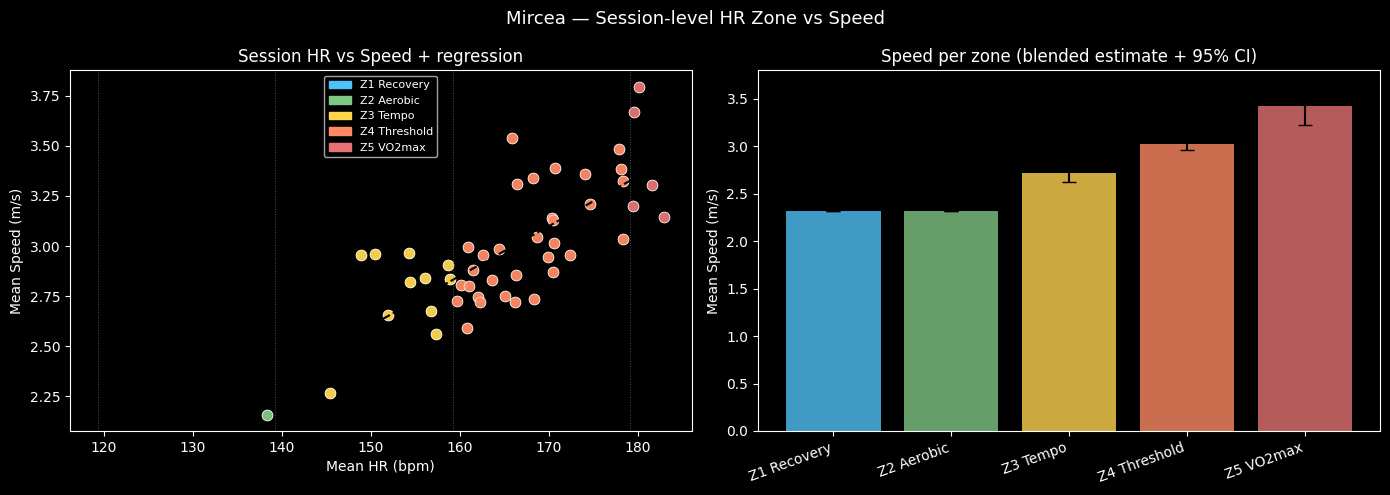

In [20]:
from scipy import stats as scipy_stats

BLEND_K   = 8    # crossover point: at n=8 empirical weight = 50%
MIN_SPEED = 1.5  # physiological floor — regression can't predict below this
MIN_N_CI  = 3    # minimum sessions to compute variance

def fmt_pace(speed_ms):
    pace = 1000 / speed_ms / 60
    mins = int(pace)
    secs = round((pace - mins) * 60)
    if secs == 60:       # carry-over guard
        mins += 1
        secs = 0
    return f'{mins}:{secs:02d} min/km'

# ── Linear regression: speed ~ mean_hr (personal aerobic profile) ───────────
reg = scipy_stats.linregress(session_stats['mean_hr'], session_stats['mean_speed'])
print(f'Regression  speed = {reg.slope:.4f} × HR + {reg.intercept:.3f}  '
      f'(R²={reg.rvalue**2:.2f}, p={reg.pvalue:.3f})')
print(f'Interpretation: {abs(reg.slope)*10:.3f} m/s per 10 bpm  '
      f'({"faster" if reg.slope > 0 else "slower"} with higher HR)\n')

hr_data_min = session_stats['mean_hr'].min()
hr_data_max = session_stats['mean_hr'].max()

def reg_predict(hr):
    hr_clamped = np.clip(hr, hr_data_min, hr_data_max)
    return max(reg.slope * hr_clamped + reg.intercept, MIN_SPEED)

# ── Blended zone estimates + 95% CI ─────────────────────────────────────────
zone_mid_hr = {
    z: (ZONE_BOUNDS[i] + ZONE_BOUNDS[i+1]) / 2 * MAX_HR
    for i, z in enumerate(ZONE_LABELS)
}

zone_estimates = {}
for z in ZONE_LABELS:
    subset   = session_stats[session_stats['hr_zone'] == z]['mean_speed'].dropna()
    n        = len(subset)
    reg_pred = reg_predict(zone_mid_hr[z])

    if n == 0:
        est    = reg_pred
        ci_lo  = ci_hi = ci_hw = None
        source = 'regression'
    else:
        emp_mean = subset.mean()
        w_emp    = n / (n + BLEND_K)
        est      = w_emp * emp_mean + (1 - w_emp) * reg_pred

        # CI only when blend is ≥50% empirical — below that it doesn't
        # bracket the blended estimate and is misleading to display.
        if n >= BLEND_K and n >= MIN_N_CI:
            se     = subset.std(ddof=1) / np.sqrt(n)
            t_crit = scipy_stats.t.ppf(0.975, df=n - 1)
            ci_lo  = emp_mean - t_crit * se
            ci_hi  = emp_mean + t_crit * se
            ci_hw  = (ci_hi - ci_lo) / 2
        else:
            ci_lo = ci_hi = ci_hw = None

        source = 'empirical' if n >= BLEND_K else f'blend ({w_emp:.0%} emp)'

    zone_estimates[z] = {
        'n': n, 'speed': est,
        'ci_lo': ci_lo, 'ci_hi': ci_hi, 'ci_hw': ci_hw,
        'source': source
    }

# ── Enforce monotonicity ─────────────────────────────────────────────────────
prev_speed = 0.0
for z in ZONE_LABELS:
    if zone_estimates[z]['speed'] < prev_speed:
        zone_estimates[z]['speed'] = prev_speed
        zone_estimates[z]['ci_lo'] = zone_estimates[z]['ci_hi'] = zone_estimates[z]['ci_hw'] = None
        zone_estimates[z]['source'] += ' [mono-corrected]'
    prev_speed = zone_estimates[z]['speed']

# ── Print summary ────────────────────────────────────────────────────────────
print(f'{"Zone":<20s} {"n":>4}  {"Speed (m/s)":>12}  {"Pace":>10}  {"95% CI (pace)":>24}  Source')
print('-' * 90)
for z in ZONE_LABELS:
    e      = zone_estimates[z]
    ci_str = (f'[{fmt_pace(e["ci_hi"])}, {fmt_pace(e["ci_lo"])}]'
              if e['ci_lo'] is not None else '           —')
    flag   = '  ⚠ low n' if 0 < e['n'] < BLEND_K else ''
    print(f'{z:<20s} {e["n"]:>4}  {e["speed"]:>7.2f} m/s  {fmt_pace(e["speed"]):>10}  {ci_str:>24}  {e["source"]}{flag}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{ATHLETE_NAME} — Session-level HR Zone vs Speed', fontsize=13)

for z, c in zip(ZONE_LABELS, ZONE_COLORS):
    sub = session_stats[session_stats['hr_zone'] == z]
    axes[0].scatter(sub['mean_hr'], sub['mean_speed'], c=c, s=60, alpha=0.8,
                    edgecolors='white', linewidths=0.5, label=z)
hr_range = np.linspace(hr_data_min, hr_data_max, 100)
axes[0].plot(hr_range, reg.slope * hr_range + reg.intercept,
             color='black', lw=1.5, ls='--', label='regression')
for b in ZONE_BOUNDS[1:-1]:
    axes[0].axvline(b * MAX_HR, color='grey', lw=0.7, ls=':', alpha=0.6)
axes[0].set_xlabel('Mean HR (bpm)')
axes[0].set_ylabel('Mean Speed (m/s)')
axes[0].set_title('Session HR vs Speed + regression')
handles = [mpatches.Patch(color=c, label=z) for z, c in zip(ZONE_LABELS, ZONE_COLORS)]
axes[0].legend(handles=handles, fontsize=8)

speeds  = [zone_estimates[z]['speed'] for z in ZONE_LABELS]
ci_errs = [zone_estimates[z]['ci_hw'] or 0 for z in ZONE_LABELS]
axes[1].bar(ZONE_LABELS, speeds, color=ZONE_COLORS, alpha=0.8,
            yerr=ci_errs, capsize=5, error_kw=dict(ecolor='black', lw=1.5))
axes[1].set_xticklabels(ZONE_LABELS, rotation=20, ha='right')
axes[1].set_ylabel('Mean Speed (m/s)')
axes[1].set_title('Speed per zone (blended estimate + 95% CI)')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/hr_zone_vs_speed.png', dpi=150)
plt.show()